# Predicting Crop Yield from Rwanda's Seasonal Agricultural Survey Microdata

**Summative Assignment:** Regression Analysis

**Name:** Selena ISIMBI

**Course:** Mathematics for Machine Learning

**Date:** 26/07/2026


## Problem Statement

Agriculture being the backbone of Rwanda's economy, is dominated by smallholder farmers who cultivate small, fragmented plots across three growing seasons (A, B, C) each year. Rwanda's National Institute of Statistics (NISR) conducts a **Seasonal Agricultural Survey (SAS)** to track what is planted, how plots are managed, and how much is harvested but this data is collected for statistical reporting, not for giving farmers an accurate prediction/estimate of what their plot is likely to yield.

Knowing the **expected yield** of a plot informs real decisions: whether a crop choice justifies the labor and input cost, whether a plot's output signals a soil or practice problem, and how much harvest to plan for. Extension officers and organizations supporting smallholder farmers can similarly use yield predictions to target advice and inputs where they are needed most.

This notebook builds a **regression model that predicts crop `Yield`** for a given plot, using plot-level characteristics already captured in the SAS Production dataset; plot size, crop type, season, and location from real survey data conducted by NISR covering 2025 Seasons A, B, and C across Rwanda.


## Project Objectives

### General Objective
The objective is to build and evaluate a regression model that predicts crop `Yield` on Rwandan smallholder plots using the 2025 Seasonal Agricultural Survey Production data (Seasons A, B, C), and to compare it against alternative regression approaches and select the best-performing model.

### Specific Objectives
1. Explore and clean the dataset - identify missing values, duplicates, incorrect data types, and outliers.

2. Engineer features - choose the relevant columns,and convert categorical variables to numeric form that the machine learning models will understand.

3. Visualize relationships between features and `Yield` before modeling.

4. Train and compare a gradient-descent linear regression model against Random Forest and Decision Tree regressors.

5. Choose and save the best-performing model, and demonstrate a single-point prediction for use in the API (next task: Task 2).


## Dataset Description

**Source:** Rwanda National Institute of Statistics (NISR) — Seasonal Agricultural Survey (SAS) 2025 Microdata Catalog: [https://www.microdata.statistics.gov.rw/index.php/catalog/124/get_microdata](https://www.microdata.statistics.gov.rw/index.php/catalog/124/get_microdata)

**What it contains:** Plot-level survey data from Rwandan farming households across the three 2025 agricultural seasons (A, B, C). This notebook uses the **Production** file from each season, recording per plot: location (province, district), farmer demographics, plot area, crop grown, and the computed **`Yield`**.

**Target variable:** `Yield` - the crop yield achieved on a given plot.

**Number of observations (combined, Seasons A+B+C):** 69,173 plots

**Number of features:** 109 raw columns (before cleaning and feature selection)


## Why This Dataset?

This dataset is appropriate for regression because it contains a genuine continuous outcome (`Yield`) that varies with measurable, real-world agricultural factors like plot size, crop type, season, and location hence making it a perfect fit for multivariate linear regression.

It is a stronger choice than the generic 'house prediction' example we have worked on multiple times in class because of these three reasons:

1. **Real stakes.** This is official national statistics data reflecting an ongoing agricultural development problem, not a disconnected textbook dataset.

2. **Genuine complexity.** Government microdata is messy in the way real-world data actually is — survey codes, missing responses, mixed data types, and multiple seasons that need to be combined and cleaned.

3. **Volume and variety.** Combining three full survey seasons gives tens of thousands of plot-level records spanning Rwanda's provinces, districts, and crop types.


## Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import SGDRegressor, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score

# Saving the best model
import joblib

%matplotlib inline
sns.set_style("whitegrid")


## Load the Dataset

The three season files are tab-delimited despite the `.csv` extension, and Season C is missing a couple of columns present in A/B (survey questionnaire differences). We load each season, tag it, and combine them into one DataFrame.


In [2]:
DATA_DIR = "../../Microdata"

season_files = {
    "A": f"{DATA_DIR}/Season A/Rwa_raw_SeasonA2025_Production.csv",
    "B": f"{DATA_DIR}/Season B/Rwa_raw_SeasonB2025_Production.csv",
    "C": f"{DATA_DIR}/Season C/Rwa_raw_SeasonC2025_Production.csv",
}

season_dfs = []
for season, file_path in season_files.items():
    df_season = pd.read_csv(file_path, sep="\t")
    df_season["Season"] = season
    season_dfs.append(df_season)

df = pd.concat(season_dfs, ignore_index=True, sort=False)

print(f"Combined shape: {df.shape}")
df.head()


C:\Users\HP\AppData\Local\Temp\ipykernel_4892\669519216.py:11: DtypeWarning: Columns (0: s2q4_o, 1: s2q27_Other_place, 2: s2q37_Other_storage) have mixed types. Specify dtype option on import or set low_memory=False.
  df_season = pd.read_csv(file_path, sep="\t")


Combined shape: (69173, 109)


C:\Users\HP\AppData\Local\Temp\ipykernel_4892\669519216.py:11: DtypeWarning: Columns (0: s2q4_Other, 1: s2q10_Other, 2: s2q27_Other_place, 3: s2q37_Other_storage, 4: s3q17, 5: s4q9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_season = pd.read_csv(file_path, sep="\t")


,Segment_ID,s1q1,s1q2,s1q3,s1q4,s1q6,s1q7,s1q8,s1q9,s1q14,...,Yield,plot_weight,Season,s2q4_Other,s2q24_disease,s2q23_Other,s2q39,s2q40,Code,Plot_weight
0,12001,Kigali,Gasabo,LSF,1,1,Large scale farmer as individual,Male,64.0,No,...,17651.5400,1.0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12001,Kigali,Gasabo,LSF,1,1,Large scale farmer as individual,Male,64.0,No,...,331.5026,1.0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12001,Kigali,Gasabo,LSF,1,1,Large scale farmer as individual,Male,64.0,No,...,29805.1300,1.0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12001,Kigali,Gasabo,LSF,1,1,Large scale farmer as individual,Male,64.0,No,...,8459.0360,1.0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12001,Kigali,Gasabo,LSF,1,1,Large scale farmer as individual,Male,64.0,No,...,8460.6200,1.0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Understand the Dataset

In [3]:
df.shape


(69173, 109)

In [4]:
df.columns.tolist()


['Segment_ID',
 's1q1',
 's1q2',
 's1q3',
 's1q4',
 's1q6',
 's1q7',
 's1q8',
 's1q9',
 's1q14',
 's1q16',
 's2q1',
 's2q2',
 's2q3',
 's2q4',
 'CropCategory',
 's2q4_o',
 's2q5',
 's2q6',
 's2q7',
 's2q8',
 's2q9',
 's2q10',
 's2q10_Other',
 's2q11',
 's2q12',
 's2q13_1',
 's2q13_2',
 's2q14',
 's2q15_a',
 's2q15_b',
 's2q16_1',
 's2q16_2',
 's2q17',
 's2q18_a',
 's2q18_b',
 's2q19_1',
 's2q19_2',
 's2q19_3',
 's2q20_1',
 's2q20_2',
 's2q21',
 's2q22',
 's2q23',
 's2q24_e1',
 's2q24_e2',
 's2q24_e3',
 's2q24_d',
 's2q25',
 's2q25_food',
 's2q25_drink',
 's2q25_other',
 's2q26',
 's2q27',
 's2q27_Other_place',
 's2q28',
 's2q29',
 's2q30',
 's2q31',
 's2q32',
 's2q33',
 's2q34',
 's2q35',
 's2q36',
 's2q37',
 's2q37_Other_storage',
 's2q37_public',
 's2q38',
 's2q41',
 's2q42',
 's2q43',
 's2q44',
 's2q45',
 's2q46',
 's2q47',
 's2q48',
 's2q49',
 's2q50',
 's3q1',
 's3q3',
 's3q7',
 's3q9',
 's3q16',
 's3q17',
 's3q18',
 's3q19',
 's4q1',
 's4q2',
 's4q3',
 's4q4',
 's4q6',
 's4q8',
 

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 69173 entries, 0 to 69172
Columns: 109 entries, Segment_ID to Plot_weight
dtypes: float64(54), int64(5), object(2), str(48)
memory usage: 57.5+ MB


In [6]:
# Missing values and duplicates in the columns relevant to a yield model
key_cols = [
    "Yield", "Plot_area_ha", "Crop_Area_ha", "Harvested_Crop_Area_ha",
    "Harvest_ratio", "plot_weight", "Plot_weight", "CropCategory",
    "s2q4", "s1q1", "s1q2", "Season",
]
print(df[key_cols].isna().sum())
print("\nFully duplicated rows:", df.duplicated().sum())


Yield                      5381
Plot_area_ha                  0
Crop_Area_ha                  0
Harvested_Crop_Area_ha     7239
Harvest_ratio              7239
plot_weight                1884
Plot_weight               67289
CropCategory                  0
s2q4                          0
s1q1                          0
s1q2                          0
Season                        0
dtype: int64

Fully duplicated rows: 0


**Findings:** `Yield` has 5,381 missing values (rows unusable for training). `Harvested_Crop_Area_ha`/`Harvest_ratio` are missing ~7,239 rows because Season C's questionnaire didn't collect them at all — excluded as features rather than losing a full season. `plot_weight`/`Plot_weight` are split by season due to a column-name case mismatch — a survey sampling weight, not a predictive feature, so excluded entirely. No fully duplicate rows.


In [7]:
candidate_cols = ["Plot_area_ha", "Crop_Area_ha", "CropCategory", "s1q1", "s1q2", "Season"]
df[candidate_cols].describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Plot_area_ha,69173.0,NaN,NaN,NaN,0.995012,17.747781,0.001702,0.043153,0.084539,0.1727,1651.444
Crop_Area_ha,69173.0,NaN,NaN,NaN,0.814773,15.764462,0.0,0.017498,0.038932,0.087183,1087.21
CropCategory,69173,21,Bush bean,10582,NaN,NaN,NaN,NaN,NaN,NaN,NaN
s1q1,69173,5,East,23909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
s1q2,69173,31,Gatsibo,4131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,69173,3,A,34369,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Numerical features:** `Plot_area_ha`, `Crop_Area_ha` (fully populated). **Categorical features:** `CropCategory` (21 crop types), `s1q1` province (5), `s1q2` district (31), `Season` (A/B/C). `s1q8` (gender) and `s1q9` (age) were explored but excluded from the final feature set -- see the note in the Feature Encoding section for why. Everything else -- survey-question codes, IDs, sampling weights -- is dropped as noise irrelevant to yield.

## Data Cleaning

In [8]:
feature_cols = ["Plot_area_ha", "Crop_Area_ha", "CropCategory", "s1q1", "s1q2", "Season"]  # gender/age dropped: negligible (gender) or very weak (age) predictive value
model_df = df[feature_cols + ["Yield"]].copy()

model_df = model_df.dropna(subset=["Yield"])                              # can't train without a target

print(model_df.shape)
model_df.isna().sum()


(63792, 7)


Plot_area_ha    0
Crop_Area_ha    0
CropCategory    0
s1q1            0
s1q2            0
Season          0
Yield           0
dtype: int64

**Outlier handling:** `Plot_area_ha` ranges up to 1,651 ha against a median of 0.087 ha, and `Yield` up to ~528,855 — values far outside smallholder farming (Rwanda's dominant and this project's target pattern). We scope to plots ≤10 ha and cap `Yield` at its 99th percentile, removing extreme values while retaining ~98% of the cleaned data.


In [9]:
before = model_df.shape[0]
model_df = model_df[model_df["Plot_area_ha"] <= 10]
model_df = model_df[model_df["Yield"] > 0]

yield_cap = model_df["Yield"].quantile(0.99)
model_df = model_df[model_df["Yield"] <= yield_cap]

print(f"Rows before: {before} -> Rows after: {model_df.shape[0]} ({before - model_df.shape[0]} removed)")
model_df[["Plot_area_ha", "Crop_Area_ha", "Yield"]].describe()


Rows before: 63792 -> Rows after: 62516 (1276 removed)


,Plot_area_ha,Crop_Area_ha,Yield
count,62516.000000,62516.000000,62516.000000
mean,0.209085,0.114494,5355.823601
std,0.620925,0.449967,5612.260709
min,0.001702,0.000402,5.702300
25%,0.043904,0.017112,689.692775
50%,0.085677,0.038190,2097.309500
75%,0.171994,0.084636,9882.824750
max,9.976667,9.976667,21937.090000


## Data Visualization

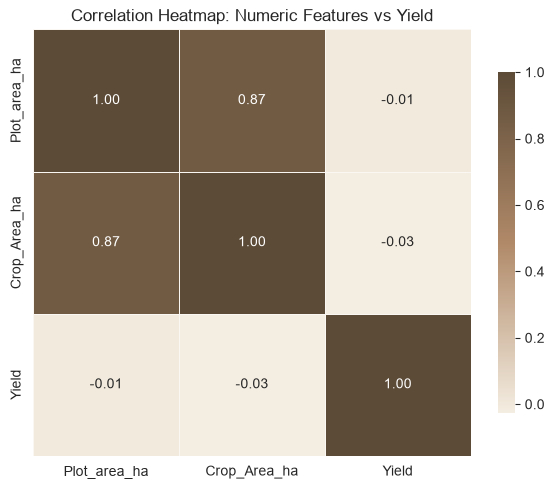

In [10]:
from matplotlib.colors import LinearSegmentedColormap

earth_cmap = LinearSegmentedColormap.from_list("earth", ["#F4EDE1", "#B08968", "#5C4B37"])
numeric_cols = ["Plot_area_ha", "Crop_Area_ha", "Yield"]

plt.figure(figsize=(6, 5))
sns.heatmap(model_df[numeric_cols].corr(), annot=True, cmap=earth_cmap, fmt=".2f",
            linewidths=0.5, linecolor="#FAF7F2", cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap: Numeric Features vs Yield")
plt.tight_layout()
plt.show()


**Interpretation:** `Plot_area_ha`/`Crop_Area_ha` correlate with `Yield` at only -0.01 to -0.03 — plot size alone is a weak linear predictor. `Plot_area_ha` and `Crop_Area_ha` correlate strongly with each other (~0.87), as expected since crop area is a subset of plot area.


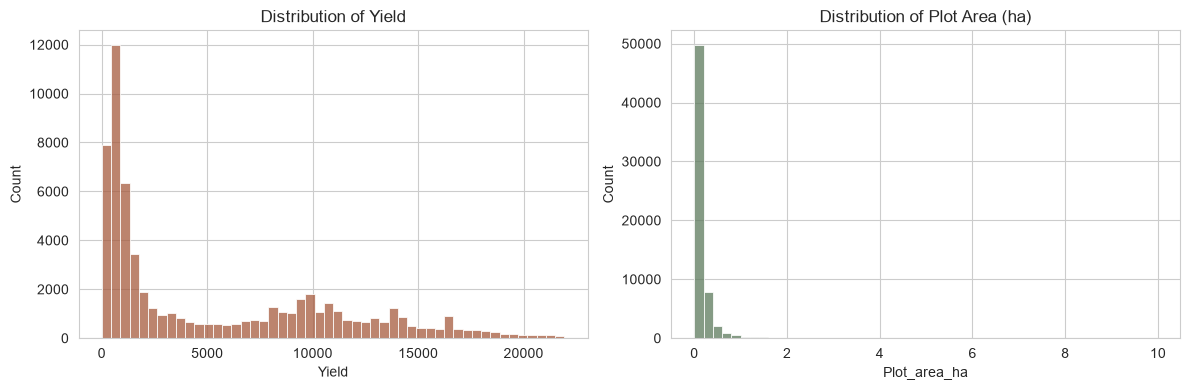

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(model_df["Yield"], bins=50, ax=axes[0], color="#A65B3E")
axes[0].set_title("Distribution of Yield")
sns.histplot(model_df["Plot_area_ha"], bins=50, ax=axes[1], color="#5C7A5C")
axes[1].set_title("Distribution of Plot Area (ha)")
plt.tight_layout()
plt.show()


**Interpretation:** both distributions are strongly right-skewed — most plots are small and most yields moderate, with a long tail even after capping. Expected for smallholder farm data.


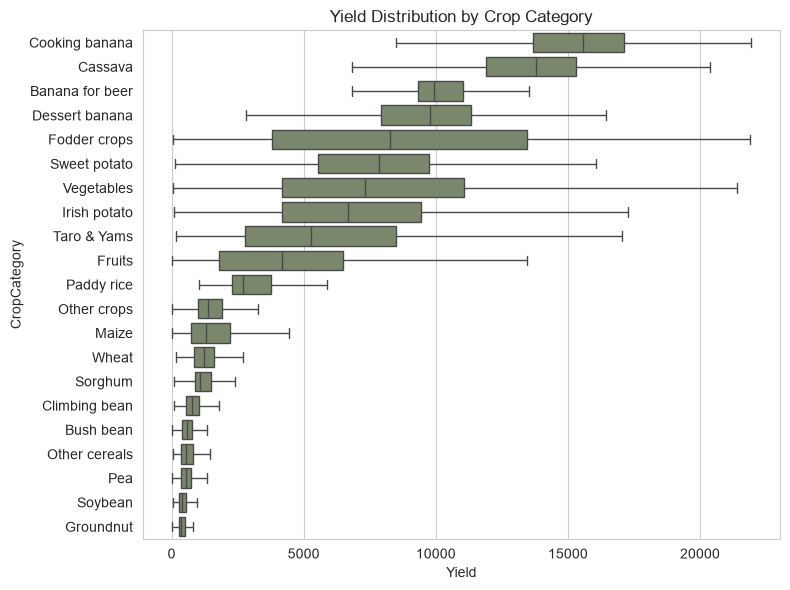

In [12]:
plt.figure(figsize=(8, 6))
crop_order = model_df.groupby("CropCategory")["Yield"].median().sort_values(ascending=False).index
sns.boxplot(data=model_df, y="CropCategory", x="Yield", order=crop_order, showfliers=False, color="#7A8B69")
plt.title("Yield Distribution by Crop Category")
plt.tight_layout()
plt.show()


**Interpretation:** large gaps between crop types — Cooking banana and Cassava medians exceed 10,000, while Groundnut and Soybean sit under 500. `CropCategory` carries far more predictive signal than plot area.


Categorical columns are one-hot encoded (`drop_first=True` avoids the dummy variable trap). We split into train/test before standardizing numeric columns, fitting the scaler on training data only, to avoid data leakage.

**Note:** `s1q8` (gender) and `s1q9` (age) were dropped from the feature set after checking feature importance -- gender contributed a combined ~0.1% (negligible), and age, while a real signal (median yield rises modestly with farmer age, correlation ~0.03), was weak enough that we chose to exclude both rather than ask users for demographic information the model barely uses.

In [13]:
categorical_cols = ["CropCategory", "s1q1", "s1q2", "Season"]
numerical_cols = ["Plot_area_ha", "Crop_Area_ha"]

encoded_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)
X = encoded_df.drop(columns=["Yield"])
y = encoded_df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Feature matrix:", X.shape, "| Train:", X_train.shape, "| Test:", X_test.shape)


Feature matrix: (62516, 58) | Train: (50012, 58) | Test: (12504, 58)


Four regressors trained on the same split: **two different scikit-learn gradient-descent linear regression implementations** -- `SGDRegressor` (plain Stochastic Gradient Descent, updates using one sample/mini-batch at a time) and `Ridge` with `solver="sag"` (Stochastic Average Gradient, a different gradient-descent variant that averages gradients across all samples for smoother convergence, with built-in L2 regularization) -- plus `RandomForestRegressor` (ensemble) and `DecisionTreeRegressor` (tree), satisfying the requirement to compare 4 regression approaches: 2 gradient-descent linear models + 1 ensemble + 1 tree.

In [14]:
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

ridge_sag_model = Ridge(solver="sag", alpha=1.0, max_iter=1000, random_state=42)
ridge_sag_model.fit(X_train_scaled, y_train)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

dt_model = DecisionTreeRegressor(max_depth=12, random_state=42)
dt_model.fit(X_train_scaled, y_train)

print("All four models trained.")


All four models trained.


In [15]:
def evaluate(name, model, X_te, y_te):
    preds = model.predict(X_te)
    mse = mean_squared_error(y_te, preds)
    return {"Model": name, "MSE": mse, "RMSE": mse ** 0.5, "R2": r2_score(y_te, preds)}

results_df = pd.DataFrame([
    evaluate("SGD Regressor (Gradient Descent)", sgd_model, X_test_scaled, y_test),
    evaluate("Ridge Regression (SAG - Stochastic Average Gradient)", ridge_sag_model, X_test_scaled, y_test),
    evaluate("Random Forest", rf_model, X_test_scaled, y_test),
    evaluate("Decision Tree", dt_model, X_test_scaled, y_test),
]).sort_values("MSE").reset_index(drop=True)

results_df


,Model,MSE,RMSE,R2
0,Random Forest,5.493869e+06,2343.900340,0.826740
1,Ridge Regression (SAG - Stochastic Average Gra...,5.561569e+06,2358.297903,0.824605
2,SGD Regressor (Gradient Descent),5.575539e+06,2361.257866,0.824164
3,Decision Tree,5.770300e+06,2402.144976,0.818022


**Selection criterion:** the best-performing model is the one with the **lowest test-set MSE** (cross-checked against R2, since both should agree on ranking) -- MSE is the direct loss metric requested by the assignment and, unlike R2, is on `Yield`'s own scale, making it easy to reason about typical prediction error in kg.

**Result:** Random Forest achieves the lowest MSE and highest R2 (~0.827), narrowly ahead of both gradient-descent linear models (SGD and Ridge-SAG, ~0.825 each -- confirming the two implementations converge to a very similar solution) and Decision Tree (~0.817). All four explain roughly 82% of yield variance -- despite plot size showing weak linear correlation, the one-hot encoded `CropCategory` carries most of the real signal. **By the lowest-MSE criterion, Random Forest is selected as the best-performing model.**

## Gradient Descent Loss Curve

`SGDRegressor.fit()` runs all iterations internally, so to visualize convergence we retrain epoch-by-epoch with `partial_fit()`, recording train/test loss (MSE) at each step.


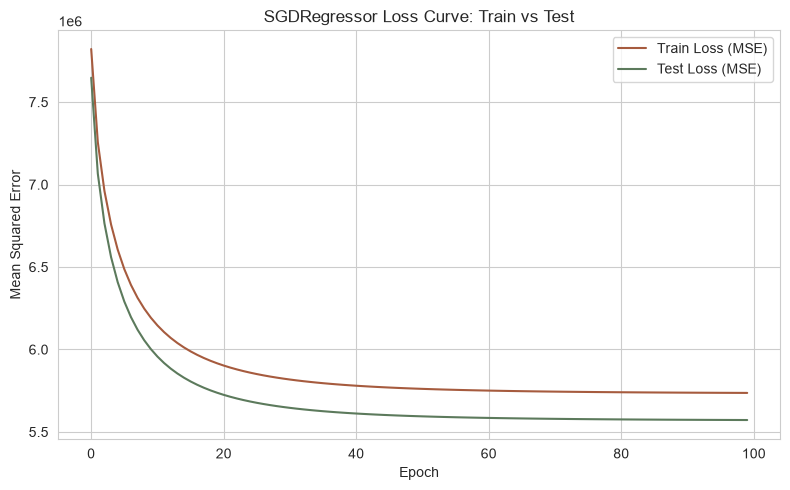

In [16]:
sgd_curve_model = SGDRegressor(max_iter=1, tol=None, warm_start=True, random_state=42)

n_epochs = 100
train_losses, test_losses = [], []

for epoch in range(n_epochs):
    sgd_curve_model.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_curve_model.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd_curve_model.predict(X_test_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss (MSE)", color="#A65B3E")
plt.plot(test_losses, label="Test Loss (MSE)", color="#5C7A5C")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SGDRegressor Loss Curve: Train vs Test")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** both curves drop sharply in early epochs and converge to a shared plateau (~5.6–5.7M MSE) with no divergence between train and test loss — steady convergence with no sign of overfitting, consistent with a linear model's limited capacity relative to 50,000 training rows.


## Before/After Scatter Plot: Actual vs Predicted

With 61 features after encoding, a single 2D regression line isn't meaningful. The multivariate equivalent is actual-vs-predicted `Yield`, with a diagonal reference line marking perfect prediction.


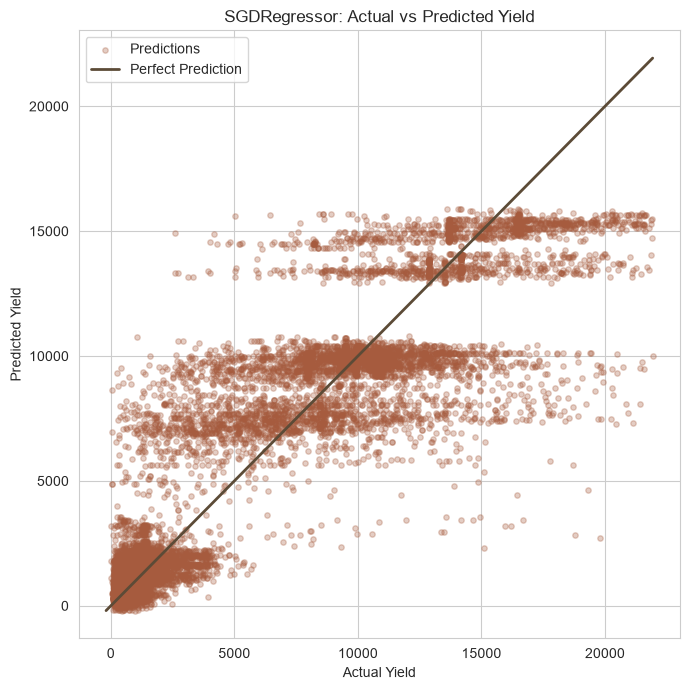

In [17]:
y_pred_sgd = sgd_model.predict(X_test_scaled)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_sgd, alpha=0.3, color="#A65B3E", s=15, label="Predictions")

lims = [min(y_test.min(), y_pred_sgd.min()), max(y_test.max(), y_pred_sgd.max())]
plt.plot(lims, lims, color="#5C4B37", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("SGDRegressor: Actual vs Predicted Yield")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** predictions cluster along the diagonal with expected spread at higher yield values (sparser data there), consistent with the ~0.82 R² reported earlier.


## Save the Best-Performing Model

Random Forest is the best performer (lowest MSE, highest R²). We save the trained model, the fitted scaler, and the exact feature column order — all three are required to correctly preprocess new input at prediction time (Task 2's API).


In [18]:
import os
os.makedirs("../API", exist_ok=True)

joblib.dump(rf_model, "../API/best_model.pkl")
joblib.dump(scaler, "../API/scaler.pkl")
joblib.dump(list(X.columns), "../API/model_columns.pkl")

print("Saved: best_model.pkl, scaler.pkl, model_columns.pkl")


Saved: best_model.pkl, scaler.pkl, model_columns.pkl


## Prediction Script

Demonstrating the saved model on a single row from the test set — the same pattern the API will use in Task 2.


In [19]:
def predict_yield(model, scaler, feature_columns, raw_input: dict) -> float:
    """
    Predict Yield from a raw feature dict (matching model_df's pre-encoding columns),
    e.g. {"Plot_area_ha": 0.09, "Crop_Area_ha": 0.05, "CropCategory": "Maize",
          "s1q1": "East", "s1q2": "Gatsibo", "Season": "A"}
    """
    input_df = pd.DataFrame([raw_input])
    input_encoded = pd.get_dummies(input_df)
    input_encoded = input_encoded.reindex(columns=feature_columns, fill_value=0)

    numerical_cols = ["Plot_area_ha", "Crop_Area_ha"]
    input_encoded[numerical_cols] = scaler.transform(input_encoded[numerical_cols])

    return float(model.predict(input_encoded)[0])


# Demonstration: predict on one actual row from the test set and compare to the true value
sample_index = X_test.index[0]
sample_raw = model_df.loc[sample_index].drop("Yield").to_dict()
actual_yield = model_df.loc[sample_index, "Yield"]

predicted_yield = predict_yield(rf_model, scaler, list(X.columns), sample_raw)

print("Input:", sample_raw)
print(f"Predicted Yield: {predicted_yield:.2f}")
print(f"Actual Yield:    {actual_yield:.2f}")


Input: {'Plot_area_ha': 0.0945196, 'Crop_Area_ha': 0.0945196, 'CropCategory': 'Cooking banana', 's1q1': 'West', 's1q2': 'Karongi', 'Season': 'A'}
Predicted Yield: 12937.33
Actual Yield:    13674.41
